In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [3]:
dates = pd.date_range(start="2025-01-01", periods=365)
zones = ["Zone1","Zone2","Zone3","Zone4","Zone5"]

data = []

for date in dates:
    for zone in zones:
        
        temp = np.random.normal(30,5)
        humidity = np.random.uniform(40,80)
        event = np.random.choice([0,1], p=[0.9,0.1])
        
        energy = 200 + temp*4 + humidity*2 + event*50 + np.random.normal(0,10)
        
        data.append([date,zone,temp,humidity,event,energy])

df = pd.DataFrame(data, columns=[
    "Date","ZoneID","AvgTemperature","Humidity","SpecialEvent","EnergyConsumption"
])

df.to_csv("energy_data.csv",index=False)

df.head()

,Date,ZoneID,AvgTemperature,Humidity,SpecialEvent,EnergyConsumption
0,2025-01-01,Zone1,29.089556,41.614187,0,403.166596
1,2025-01-01,Zone2,29.665875,45.149319,0,405.365773
2,2025-01-01,Zone3,27.046381,47.497355,0,397.459897
3,2025-01-01,Zone4,26.614448,55.899183,0,415.379978
4,2025-01-01,Zone5,24.606874,45.999316,1,431.631822


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month

df.isnull().sum()

Date                 0
ZoneID               0
AvgTemperature       0
Humidity             0
SpecialEvent         0
EnergyConsumption    0
Month                0
dtype: int64

In [5]:
monthly = df.groupby("Month")["EnergyConsumption"].mean()
print(monthly)

Month
1     447.937143
2     444.478366
3     445.559147
4     440.897229
5     443.503565
6     446.223674
7     450.637513
8     445.276391
9     444.663013
10    448.711614
11    445.256627
12    442.847481
Name: EnergyConsumption, dtype: float64


In [6]:
zone_avg = df.groupby("ZoneID")["EnergyConsumption"].mean()
print(zone_avg)

ZoneID
Zone1    442.811442
Zone2    446.551414
Zone3    444.846274
Zone4    444.616347
Zone5    448.780949
Name: EnergyConsumption, dtype: float64


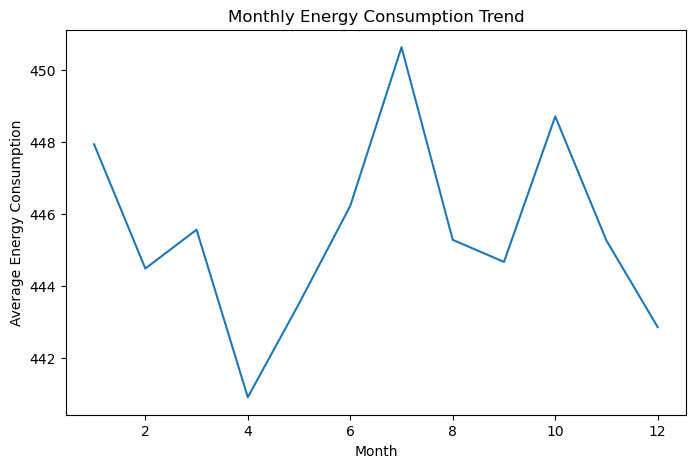

In [7]:
plt.figure(figsize=(8,5))
monthly.plot()
plt.title("Monthly Energy Consumption Trend")
plt.xlabel("Month")
plt.ylabel("Average Energy Consumption")
plt.show()

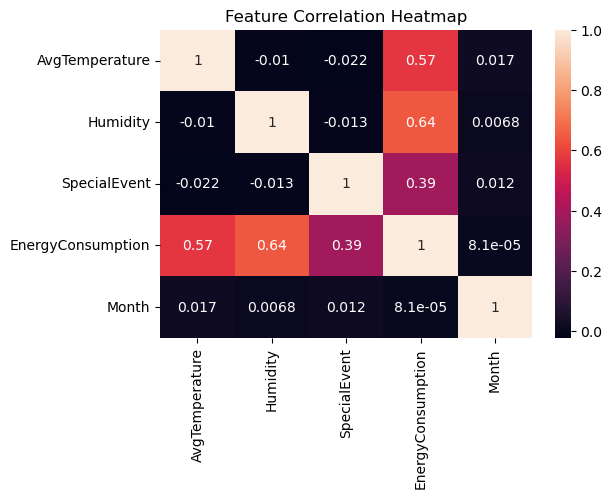

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

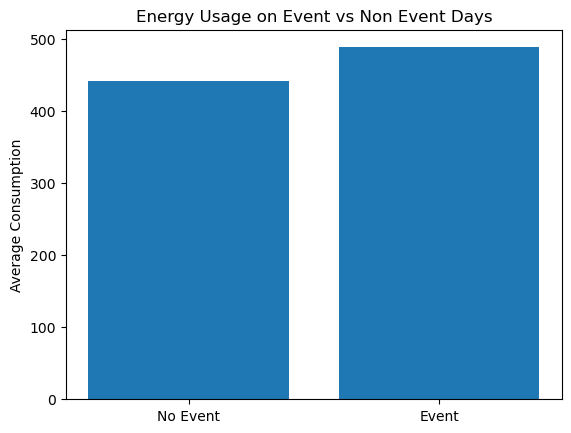

In [9]:
event_data = df.groupby("SpecialEvent")["EnergyConsumption"].mean()

plt.bar(["No Event","Event"], event_data)
plt.title("Energy Usage on Event vs Non Event Days")
plt.ylabel("Average Consumption")
plt.show()

In [20]:
X = df[["AvgTemperature","Humidity","SpecialEvent"]]
y = df["EnergyConsumption"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [12]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
predictions = model.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test,predictions)

print("Mean Absolute Error:",mae)

Mean Absolute Error: 8.167028032147849


In [16]:
print("Electricity Consumption Prediction")

zone = input("Enter Zone ID: ")
temp = float(input("Enter Tomorrow Temperature: "))
humidity = float(input("Enter Tomorrow Humidity: "))
event = int(input("Special Event? (0 or 1): "))

prediction = model.predict([[temp,humidity,event]])

print("Predicted Energy Consumption:",prediction[0],"kWh")

Electricity Consumption Prediction


Enter Zone ID:  zone1
Enter Tomorrow Temperature:  32
Enter Tomorrow Humidity:  60
Special Event? (0 or 1):  1


Predicted Energy Consumption: 497.87364819673735 kWh


C:\Users\patel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
try:
    temp = float(input("Temperature: "))
    humidity = float(input("Humidity: "))
    event = int(input("Event (0/1): "))
    
    result = model.predict([[temp, humidity, event]])
    
    print("Predicted Energy:", result[0])
    
except:
    print("Invalid input! Please enter correct values.")

Temperature:  30
Humidity:  60
Event (0/1):  1


Predicted Energy: 489.71376871064126


C:\Users\patel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


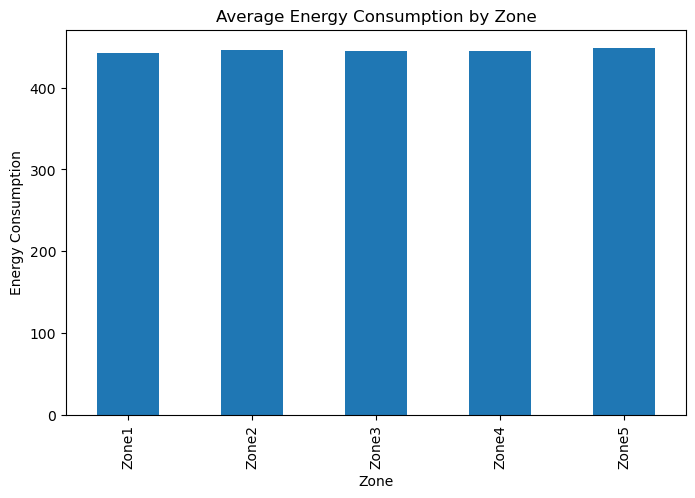

In [18]:
zone_energy = df.groupby("ZoneID")["EnergyConsumption"].mean()

plt.figure(figsize=(8,5))
zone_energy.plot(kind="bar")
plt.title("Average Energy Consumption by Zone")
plt.xlabel("Zone")
plt.ylabel("Energy Consumption")
plt.show()

In [19]:
features = ["AvgTemperature","Humidity","SpecialEvent"]

importance = model.coef_

for f,i in zip(features,importance):
    print(f,"impact:",i)

AvgTemperature impact: 4.079939743048024
Humidity impact: 2.0155259633074536
SpecialEvent impact: 49.62534718911987


In [21]:
print("Mean Absolute Error:",mae)

Mean Absolute Error: 8.167028032147849
